In [7]:
import pandas as pd
df =pd.read_csv(r"C:\Users\Jasminder\Downloads\archive(6)\Mall_Customers.csv")
print(df.head())

   CustomerID   Genre  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40


In [8]:
print("Rows and Columns:", df.shape)

# Data types
print(df.dtypes)

# Missing values
print(df.isnull().sum())

Rows and Columns: (200, 5)
CustomerID                 int64
Genre                     object
Age                        int64
Annual Income (k$)         int64
Spending Score (1-100)     int64
dtype: object
CustomerID                0
Genre                     0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


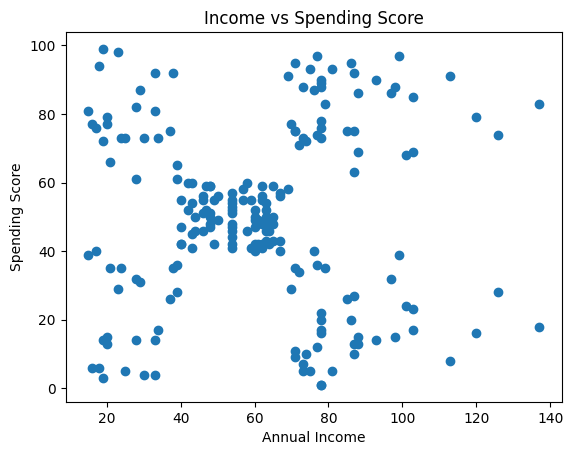

In [9]:
import matplotlib.pyplot as plt

plt.scatter(df['Annual Income (k$)'],
            df['Spending Score (1-100)'])

plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.title("Income vs Spending Score")
plt.show()

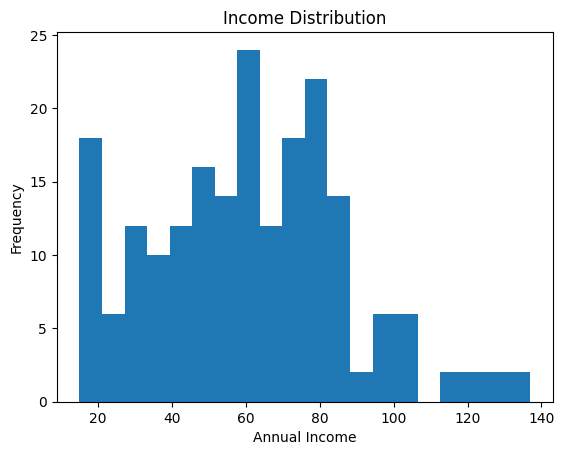

In [10]:
plt.hist(df['Annual Income (k$)'], bins=20)

plt.xlabel("Annual Income")
plt.ylabel("Frequency")
plt.title("Income Distribution")
plt.show()

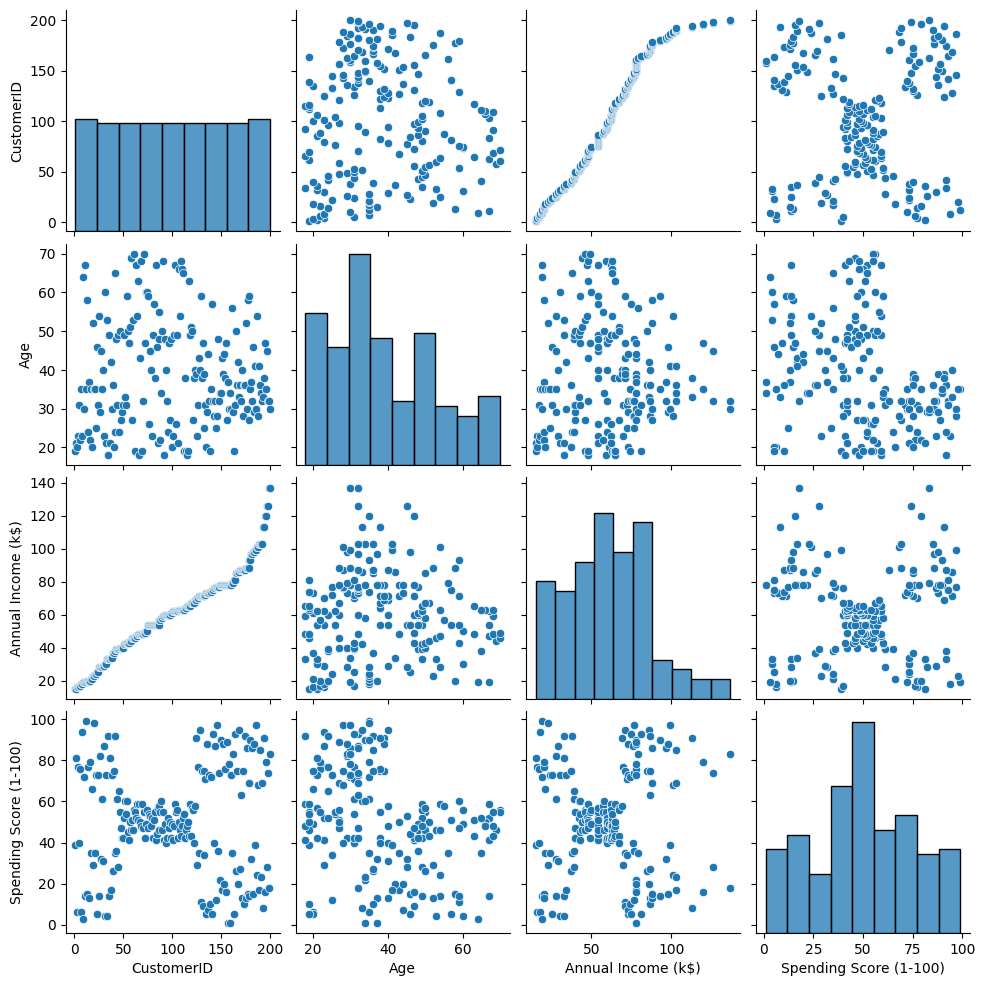

In [11]:
import seaborn as sns

sns.pairplot(df)
plt.show()

In [12]:
from sklearn.cluster import KMeans

# Selecting features
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

# Applying KMeans
kmeans = KMeans(n_clusters=5, random_state=42)

# Predict clusters
df['Cluster'] = kmeans.fit_predict(X)

print(df.head())

   CustomerID   Genre  Age  Annual Income (k$)  Spending Score (1-100)  \
0           1    Male   19                  15                      39   
1           2    Male   21                  15                      81   
2           3  Female   20                  16                       6   
3           4  Female   23                  16                      77   
4           5  Female   31                  17                      40   

   Cluster  
0        4  
1        2  
2        4  
3        2  
4        4  


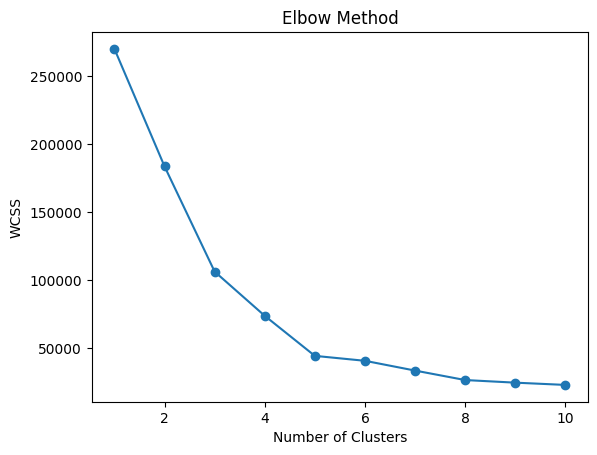

In [13]:
wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

plt.plot(range(1,11), wcss, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()


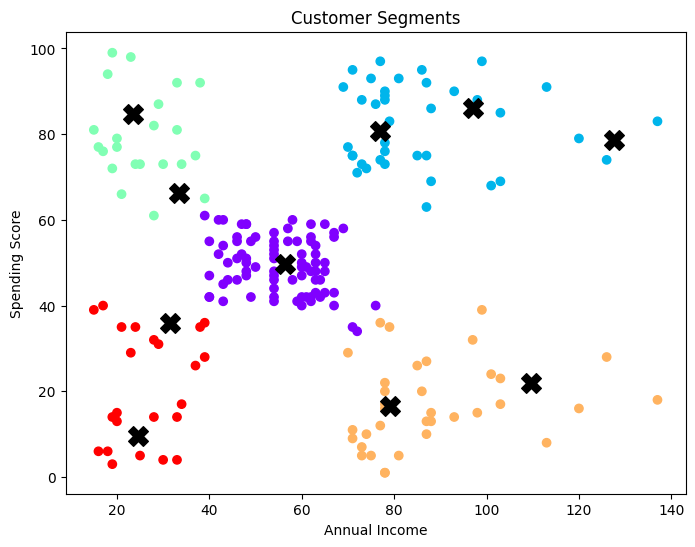

In [14]:
plt.figure(figsize=(8,6))

plt.scatter(X.iloc[:,0],
            X.iloc[:,1],
            c=df['Cluster'],
            cmap='rainbow')

# Centroids
plt.scatter(kmeans.cluster_centers_[:,0],
            kmeans.cluster_centers_[:,1],
            s=200,
            c='black',
            marker='X')

plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.title("Customer Segments")
plt.show()

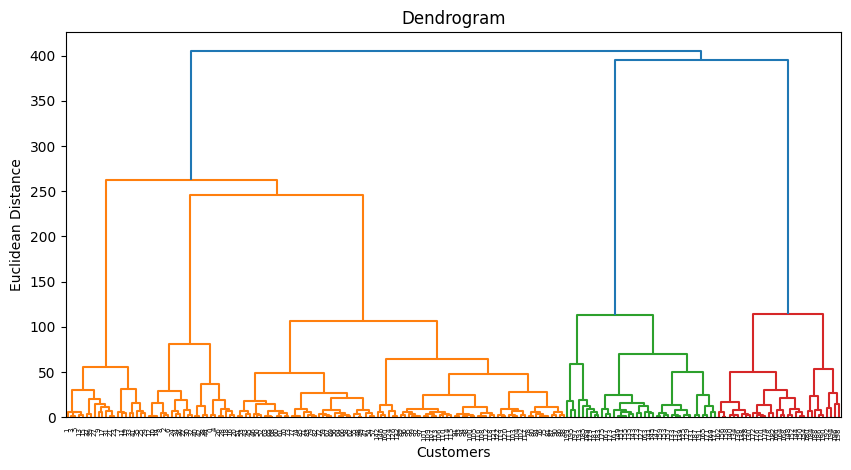

In [15]:
import scipy.cluster.hierarchy as sch

# Dendrogram
plt.figure(figsize=(10,5))

dendrogram = sch.dendrogram(
    sch.linkage(X, method='ward')
)

plt.title("Dendrogram")
plt.xlabel("Customers")
plt.ylabel("Euclidean Distance")
plt.show()